# Data Worth

This notebook explores computing data worth for a Pastas model.

## What are we computing?

We want to quantify the importance of (groups of) observations for the performance of
our time series model. The performance of a model is dictated by the magnitude of
uncertainty of the parameters. Changes in this uncertainty are interpreted as a proxy
for data worth.

We use the Jacobian and make some assumptions to investigate the effect of removing
observations on the computed parameter covariance matrix. The change in parameter
covariance tells us whether our parameters are less constrained when observations are
removed, indicating a loss of information. This computed value of the loss of
information is an indication of data worth. A bigger loss means this observation or
group of observations was relatively important in the uncertainty estimates of the
parameters. A small loss means this parameter was not as important in the uncertainty
estimates of the parameters.

## Approximations

Some approximations that are made when performing this analysis:

- Assumes linearity (Jacobian doesn't change if parameter moves).
- Errors are normally distributed (multi-gaussian).
- Static covariance (when removing observations, the variance of the noise remains constant).

---

Let' s get started with an example.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pastas as ps
from scipy.optimize import curve_fit

from pastas_plugins import dataworth as ppdw

Import some data.

In [2]:
datadir = Path("../../../pastas/doc/examples/data/")
obs = pd.read_csv(datadir / "head_nb1.csv", index_col=0, parse_dates=True).squeeze(
    "columns"
)
rain = pd.read_csv(datadir / "rain_nb1.csv", index_col=0, parse_dates=True).squeeze(
    "columns"
)
evap = pd.read_csv(datadir / "evap_nb1.csv", index_col=0, parse_dates=True).squeeze(
    "columns"
)

Build a time series model and solve it.

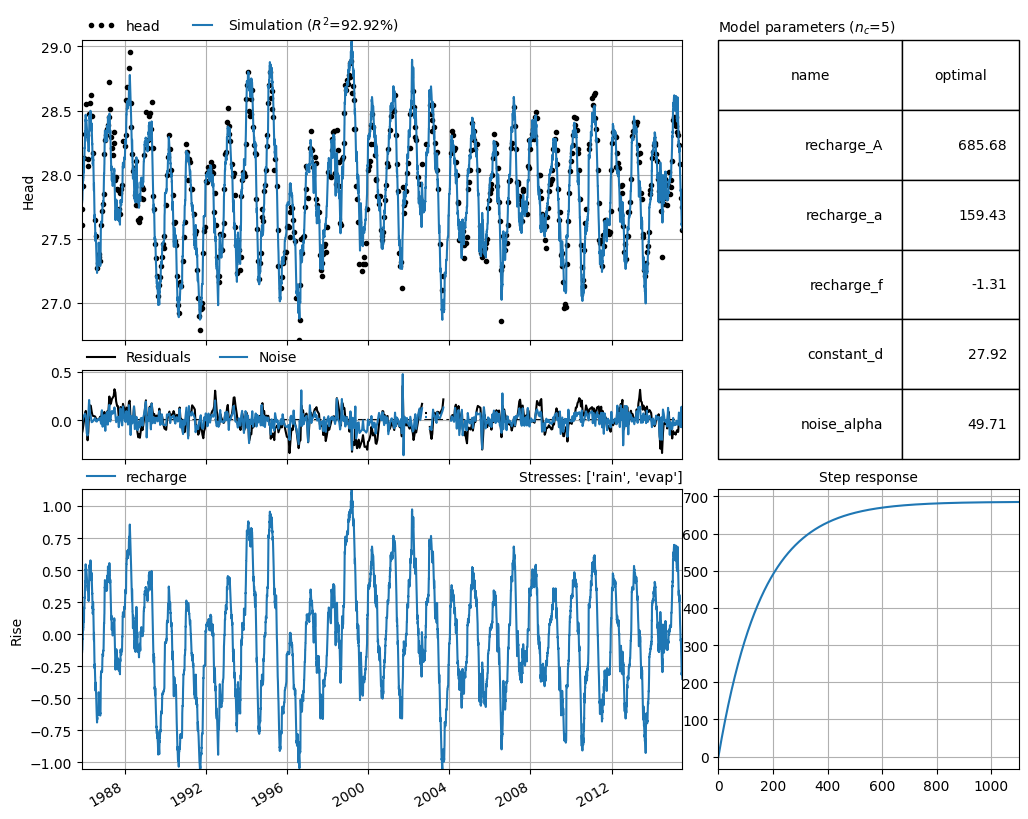

In [3]:
ml = ps.Model(obs, name="head")
sm = ps.RechargeModel(prec=rain, evap=evap, rfunc=ps.Exponential(), name="recharge")
ml.add_stressmodel(sm)
ml.solve(report=False)
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(report=False, initial=False)
axes = ml.plots.results()

## Computing Data Worth

After solving a time series model, we use the resulting Jacobian $J$ and the noise (or
residuals) to compute the parameter covariance $C_p$.

$ C_p = \left( J^T C_{\epsilon}^{-1} J \right)^{-1}$

Where $C_{\epsilon}$ is the observation noise covariance matrix. This matrix contains
the variances of the observation noise on the diagonal, and optionally the covariances
between the observations on the off-diagonal elements. The part of this equation
between the parentheses is also known as the Fisher Information Matrix. For
$C_{\epsilon}$, if we use an identity matrix $I$ multiplied by the variance of the
observation noise, we assume that all observations are independent (see below for an
analysis of when that approximation is defensible).

$C_\epsilon = \sigma^2 I $

Once we have computed the full parameter covariance matrix we can start modifying the
Jacobian and observation noise covariance matrix, to investigate the effect of removing
(groups of) observations on the parameter covariance matrix. We can then compute
statistics on this matrix to quantify the loss of information overall, or per
parameter.

A simple example is to remove one observation. We mask out the row of the Jacobian
associated with observation $k$, and likewise remove the row/column associated with
this observation in $C_\epsilon$.

$C_{p,k} = \left( J_k^T C_{\epsilon, k}^{-1} J_k \right)^{-1}$

This now gives us a modified parameter covariance matrix we can compare with our full
parameter covariance matrix. Two statistics we can use to determine the change in this
matrix are the log determinant and parameter variances (diagonal elements of the
parameter covariance matrix).

### Accounting for autocorrelation in the observation noise covariance matrix.

The observation noise covariance matrix can be computed in terms of **noise** (i.e.
the result after applying a noisemodel to the residuals) or in terms of **residuals**.

When using noise space, the AR(1) noisemodel removes the temporal autocorrelation from
the residuals. If the noise model is working well, the noise values are close to
independent, so assuming a diagonal $C_\epsilon$ is reasonable. Each noise value
carries genuinely new information.

When computing in **residual space**, autocorrelation is still present between
observations. To account for this, the off-diagonal elements of $C_\epsilon$ are
populated using an AR(1) exponential decay model:

$C_\epsilon \left[i, j\right] = \sigma^2 \exp \left( -\frac{|t_i - t_j|}{\alpha} \right)$

Where $\sigma^2$ is the residual variance and $\alpha$ is the decay length (days).
A larger $\alpha$ means stronger correlation — observations close in time carry
less independent information, and the worth of a new nearby observation is discounted
accordingly. This is the preferred approach when evaluating the worth of **adding new
observations**, since it correctly penalizes additions that are temporally redundant
with existing data.

In practice:
- Use `objfun_target="noise"` for the leave-one-out and thinning analyses (observations already used in calibration; the noise model decorrelates them).
- Use `objfun_target="residuals"` with an appropriate `noise_alpha` when evaluating **new** observations (residual space + correlated $C_\epsilon$ penalises temporally clustered additions).

---


The `DataWorth` class from the `pastas_plugins.dataworth` plugin is our entrypoint into
this analysis. It takes a pastas Model as its input argument. 

In [4]:
dw = ppdw.DataWorth(ml)

### Data worth per observation

The data worth per observation is computed by iteratively masking out one observation and computing the change in parameter covariances. The result includes both the overall change in the parameter uncertainty as well as the relative change in variance per parameter.

---

#### Quantifying change in overall uncertainty

The log-determinant of the parameter covariance matrix is a expression of the volume of
the parameter uncertainty ellipsoid (this is also known as D-optimality criterion). A
change in the volume of this ellipsoid, i.e. if it increases in size because we dropped
an observation, this value expresses the magnitude of loss of information (the increase
in uncertainty caused by dropping this observation). This then is an expression of
overall data worth of observation $k$. An increase in the log determinant indicates the
observation had positive worth, i.e. its removal increased uncertainty.

$\Delta_k \log |C_p| = \log |C_{p,k}| - \log |C_p|$

This value can be converted to a generalized ratio of standard errors by

$ r = \exp \left( \frac{\Delta_k \log |C_p|}{2 N} \right)$

Where $N$ is the number of parameters. This is indicates the average increase in
standard error per parameter.

---

#### Data worth for specific parameters

Similar to above we can compute the data worth of observation $k$ by looking at the
change in variance for a specific parameter $j$.

$ \Delta \sigma^2_j = \left[C_{p,k}\right]_{jj} - \left[C_p\right]_{jj}$

This tells us how much the variance increased as a result of dropping observation $k$.
The uncertainty in parameter $j$ increasing gives us a value of the data worth of
observation $k$. 

Instead of expressing this as an absolute change in variance, this can
be related to the base parameter variance to obtain a value that can be compared
between parameters.

$\delta_{j,k} \sigma^2  = \frac{\left[C_{p,k}\right]_{jj} - \left[C_p\right]_{jj}}{\left[C_p\right]_{jj}} $

This can be converted to a relative change in standard error as compared to the model
with all observations with

$r_j = \sqrt{ \delta_{j,k} \sigma^2 + 1 }$

---

Computing the data worth per observation is done with `dw.data_worth_per_observation()`.

In [5]:
dfdw = dw.data_worth_per_observation()

Data Worth (existing obs):   0%|          | 0/644 [00:00<?, ?it/s]

This gets us the data worth expressed as the change in log-determinant for the overall data worth, and the relative change in parameter variance for each parameter. In order to better compare the results, we convert them to percentage change in standard errors.

In [6]:
# Convert raw data worth metrics to percentage increase in standard error.
# For the overall metric (log-det): r = exp(Δlogdet / 2N), expressed as (r-1)*100 %.
# For per-parameter: r_j = sqrt(1 + δσ²_j), expressed as (r_j-1)*100 %.
# A value of 0 % means the observation had no effect; positive values indicate
# how much the std error would inflate if that observation were removed.
N = ml.parameters.index.size
dfdw.iloc[:, 0] = (np.exp(dfdw.iloc[:, 0] / (2 * N)) - 1) * 100
dfdw.iloc[:, 1:] = ((1 + dfdw.iloc[:, 1:]).pow(0.5) - 1) * 100

# update column names accordingly
dfdw.columns = [
    "Increase in gen. std. err. (%)",
    "$\Delta\sigma$ recharge_A (%)",
    "$\Delta\sigma$ recharge_a (%)",
    "$\Delta\sigma$ recharge_f (%)",
    "$\Delta\sigma$ constant_d (%)",
    "$\Delta\sigma$ noise_alpha (%)",
]

The `pastas_plugins.dataworth` module has two plot methods:

- `plot_data_worth_series()` plots each observation with markers that are sized and
colored to reflect the computed data worth, both overal and for each parameter.
- `plot_data_worth_heatmap()` which plots a heatmap for a single data worth time series
with years on the y-axis and months on the y-axis.

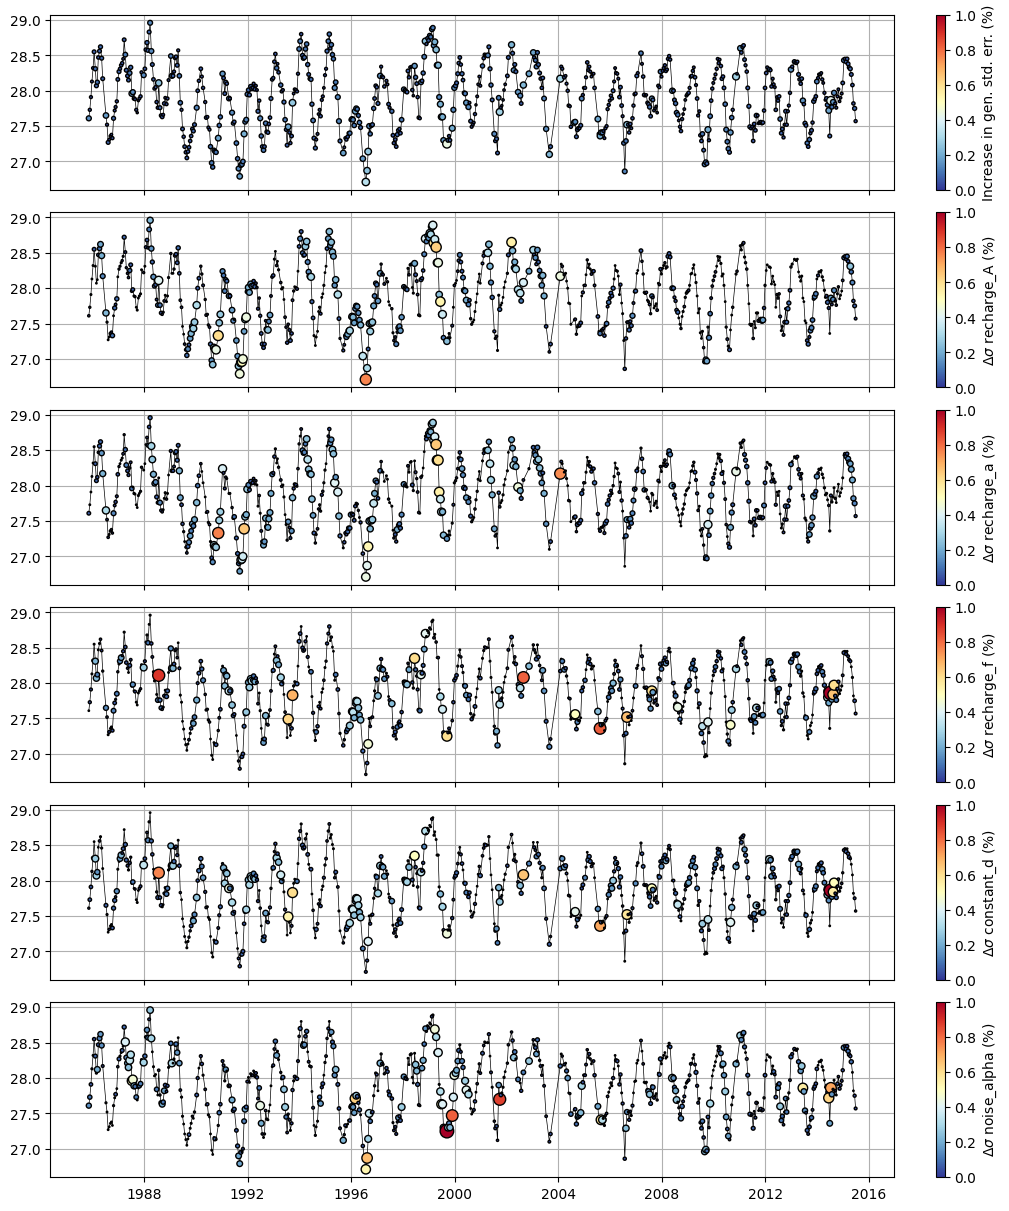

In [7]:
axes = ppdw.plot_data_worth_series(
    ml.observations(), dfdw, compute_sizes_per_plot=False, vmin=0, vmax=1
)

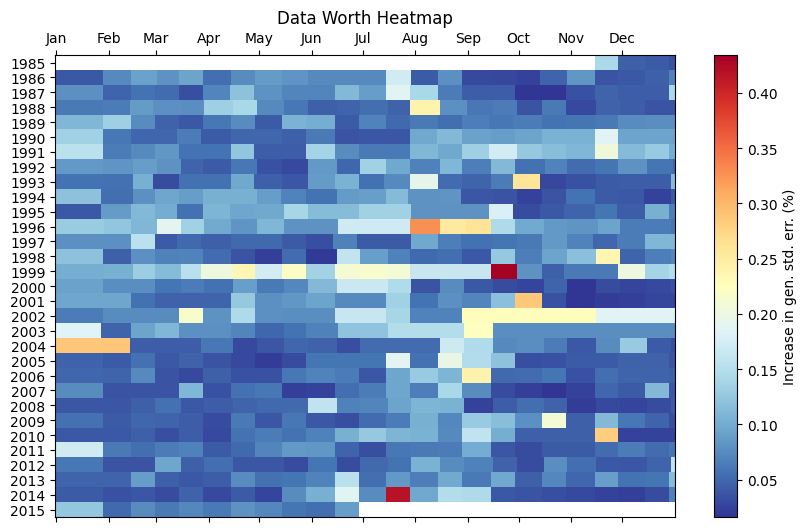

In [8]:
ax = ppdw.plot_data_worth_heatmap(dfdw["Increase in gen. std. err. (%)"])

Another analysis we can do is to compute the data worth to quantify the cost of
thinning the observation data. This can be done with `data_worth_thinning()` method,
which takes a list of thinning factors as its input. The increase in uncertainty is
"cost" of thinning.

In [9]:
thinning_intervals = [2, 3, 4, 6, 13, 26]
dwthinning, dw_params_thinning = dw.data_worth_thinning(thinning_intervals)

We can plot this result, converting the computed data worth into a relative change in
mean standard errors for all parameters.

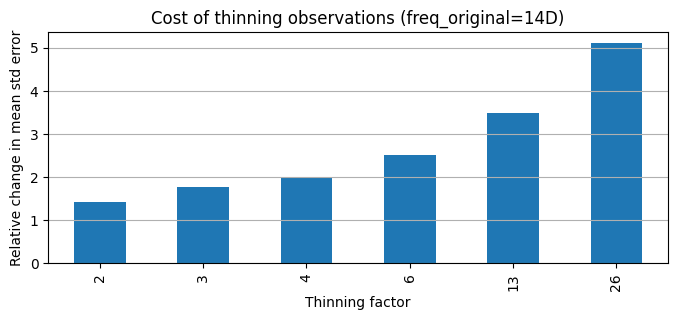

In [10]:
ax = np.exp(dwthinning / (2 * ml.parameters.index.size)).plot.bar(figsize=(8, 3))
ax.set_xlabel("Thinning factor")
ax.set_ylabel("Relative change in mean std error")
ax.set_title("Cost of thinning observations (freq_original=14D)")
ax.grid(True, axis="y")

Plot the same result but now for the parameter specifically.

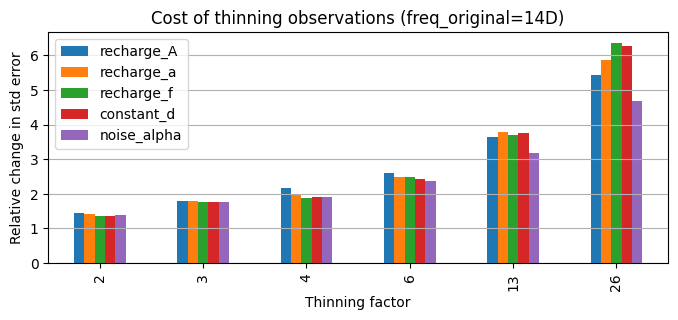

In [11]:
# compute ratios of std errors for each parameter
ax = (dw_params_thinning + 1).pow(0.5).plot.bar(figsize=(8, 3))
ax.set_xlabel("Thinning factor")
ax.set_ylabel("Relative change in std error")
ax.set_title("Cost of thinning observations (freq_original=14D)")
ax.grid(True, axis="y")

--- 

## Data Worth with multiple stresses

Now let's look at a different example, for a time series model affected by both
recharge and pumping.

In [12]:
head = pd.read_csv(
    "../../../pastas/doc/examples/data_notebook_5/head_wellex.csv",
    index_col="Date",
    parse_dates=True,
).squeeze("columns")
rain = pd.read_csv(
    "../../../pastas/doc/examples/data_notebook_5/prec_wellex.csv",
    index_col="Date",
    parse_dates=True,
).squeeze("columns")
evap = pd.read_csv(
    "../../../pastas/doc/examples/data_notebook_5/evap_wellex.csv",
    index_col="Date",
    parse_dates=True,
).squeeze("columns")
well = (
    pd.read_csv(
        "../../../pastas/doc/examples/data_notebook_5/well_wellex.csv",
        index_col="Date",
        parse_dates=True,
    )
    / 1e6
    * 365
).squeeze("columns")

Build the time series model.

In [13]:
tmax = None
fit_constant = True
freq_obs = "14D"

# Create the time series model
ml = ps.Model(head, name="head")
rm = ps.RechargeModel(prec=rain, evap=evap, rfunc=ps.Exponential(), name="recharge")
ml.add_stressmodel(rm)
sm = ps.StressModel(well, rfunc=ps.Exponential(), name="well", up=False)
ml.add_stressmodel(sm)
ml.solve(report=False, freq_obs=freq_obs, tmax=tmax, fit_constant=fit_constant)
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(
    initial=False, report=False, freq_obs=freq_obs, tmax=tmax, fit_constant=fit_constant
)

Plot the model results.

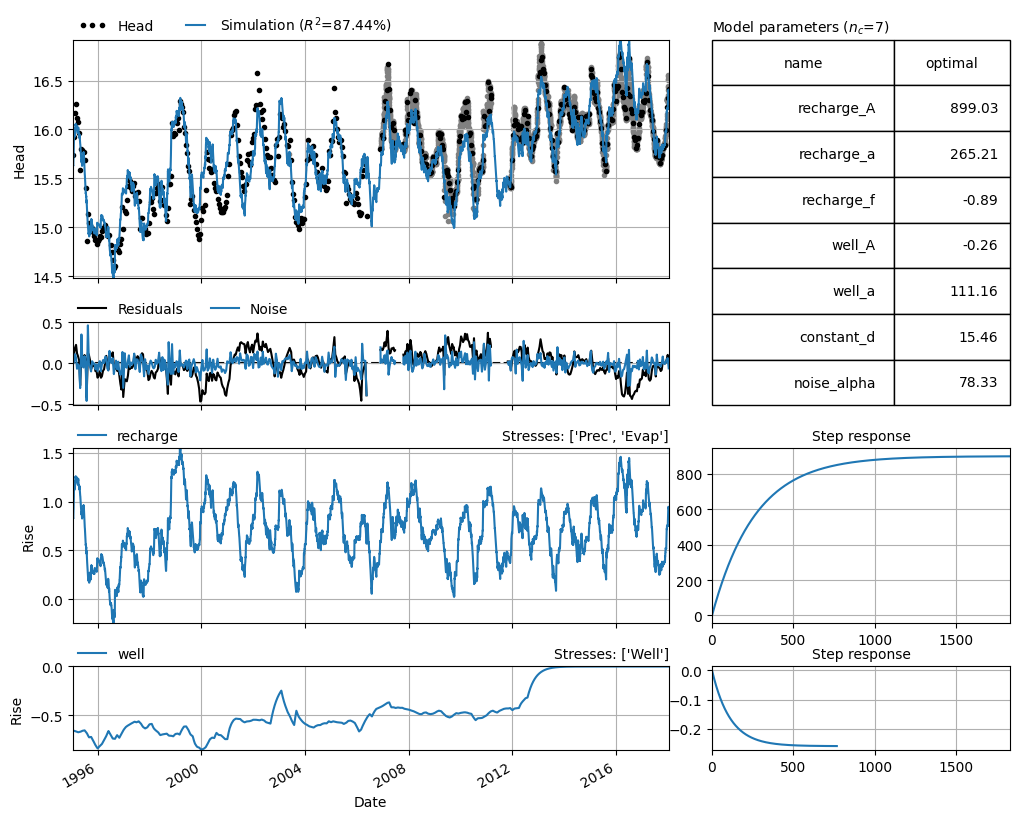

In [14]:
ml.plots.results();

Compute the data worth.

In [15]:
dw = ppdw.DataWorth(ml)

In [16]:
dfdw = dw.data_worth_per_observation()

Data Worth (existing obs):   0%|          | 0/543 [00:00<?, ?it/s]

In [17]:
N = ml.parameters.index.size
dfdw.iloc[:, 0] = (np.exp(dfdw.iloc[:, 0] / (2 * N)) - 1) * 100
dfdw.iloc[:, 1:] = ((1 + dfdw.iloc[:, 1:]).pow(0.5) - 1) * 100

# update column names accordingly
dfdw.columns = [
    "$\Delta$ gen. std. err. (%)",
    "$\Delta\sigma$ recharge_A (%)",
    "$\Delta\sigma$ recharge_a (%)",
    "$\Delta\sigma$ recharge_f (%)",
    "$\Delta\sigma$ well_A (%)",
    "$\Delta\sigma$ well_a (%)",
    "$\Delta\sigma$ constant_d (%)",
    "$\Delta\sigma$ noise_alpha (%)",
]

Plot the results. From these plots the most interesting result (which makes a lot of
sense) is that the period in which the well was switched off is relatively important to
estimate the uncertainty of the gain of the response to pumping.

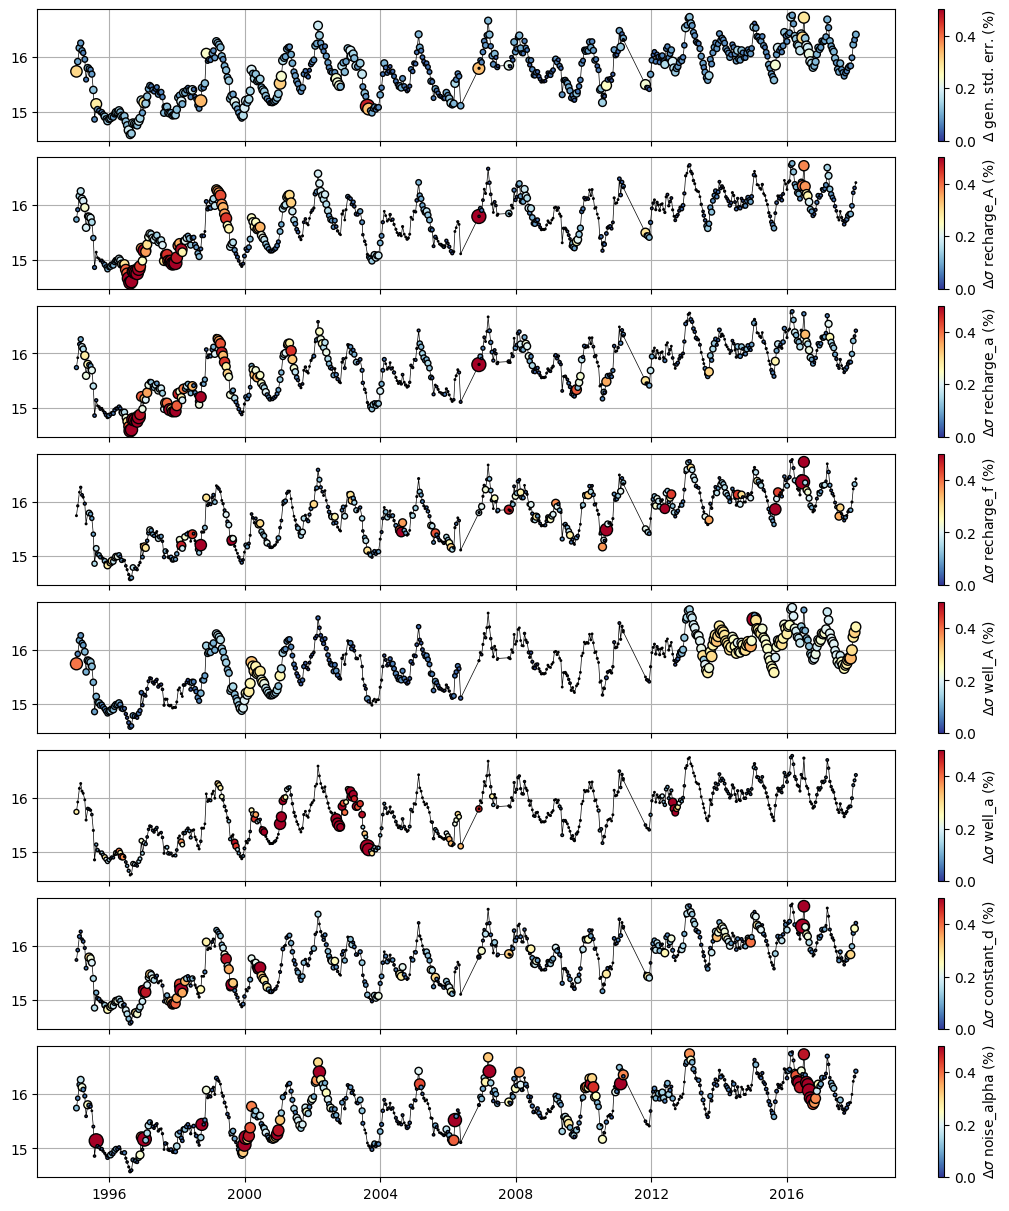

In [18]:
axes = ppdw.plot_data_worth_series(
    ml.observations(), dfdw, compute_sizes_per_plot=True, vmin=0, vmax=0.5
)

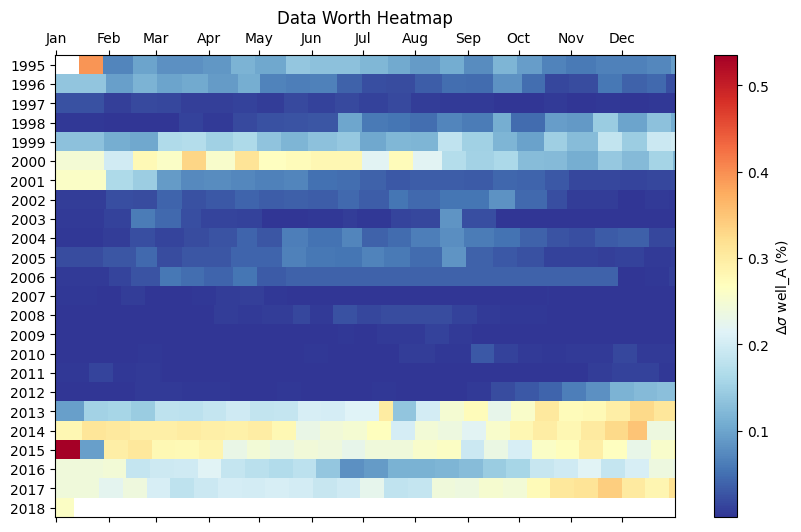

In [19]:
ax = ppdw.plot_data_worth_heatmap(dfdw["$\Delta\sigma$ well_A (%)"])

In [20]:
thinning_intervals = [2, 3, 4, 6, 13, 26]
dwthinning, dw_params_thinning = dw.data_worth_thinning(thinning_intervals)

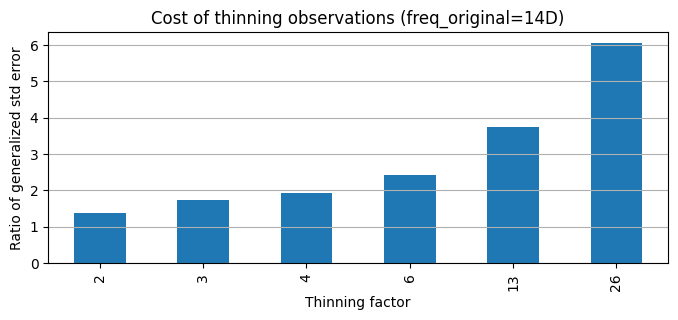

In [21]:
ax = np.exp(dwthinning / (2 * ml.parameters.index.size)).plot.bar(figsize=(8, 3))
ax.set_xlabel("Thinning factor")
ax.set_ylabel("Ratio of generalized std error")
ax.set_title("Cost of thinning observations (freq_original=14D)")
ax.grid(True, axis="y")

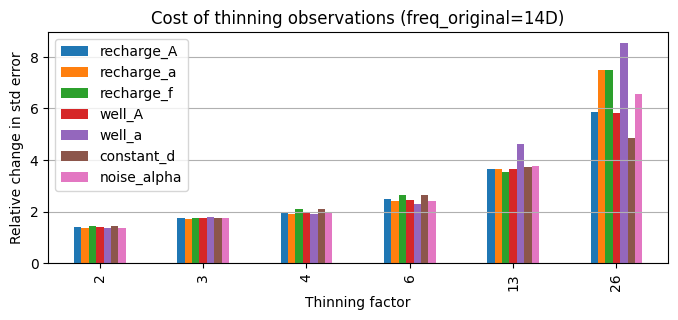

In [22]:
# compute ratios of std errors for each parameter
ax = (dw_params_thinning + 1).pow(0.5).plot.bar(figsize=(8, 3))
ax.set_xlabel("Thinning factor")
ax.set_ylabel("Relative change in std error")
ax.set_title("Cost of thinning observations (freq_original=14D)")
ax.grid(True, axis="y")

### Bonus: update model pcov to compute updated confidence intervals

We can use the linear approximation of the updated parameter covariance matrix to draw
confidence intervals using the original time series model. We can recompute the 

In [23]:
obs = ml.observations()
J0 = dw.J0

# weighted objective vector used by the noise-space least-squares solver
v = (ml.noise() * ml._noise_weights()).values

ci_dict = {0: ml.solver.ci_contribution(name="well", n=1000)}

for i in thinning_intervals:
    mask = np.zeros_like(obs.values, dtype=bool)
    mask[::i] = True

    # cost must be consistent with the same thinned objective vector used in J0[mask]
    cost_mask = 0.5 * np.sum(v[mask] ** 2)

    # create a copy of the original model
    mlc = ml.copy()
    # copy in the original pcov matrix
    mlc.solver.pcov = ml.solver.pcov.copy()
    # update the parameter covariance from the masked Jacobian and masked cost
    mlc.solver.pcov.loc[:, :] = mlc.solver.get_covariances(J0[mask], cost_mask)
    ci_sim = mlc.solver.ci_contribution(name="well", n=1000)
    ci_dict[i] = ci_sim

**Note:** The covariance update above is a local linearized estimate around the original calibrated model. A fully refit model at `freq_obs="28D"` can still produce different confidence intervals because the optimum parameters, Jacobian, noise model fit, and residual variance scaling are all re-estimated.

In [24]:
tf = 3

tmax = None
fit_constant = True
# freq_obs = f"{tf*14}D"
freq_obs = None

obs_calib = ml.observations().index[::tf]

# Create the time series model
ml2 = ps.Model(head.loc[obs_calib], name="head")
rm = ps.RechargeModel(prec=rain, evap=evap, rfunc=ps.Exponential(), name="recharge")
ml2.add_stressmodel(rm)
sm = ps.StressModel(well, rfunc=ps.Exponential(), name="well", up=False)
ml2.add_stressmodel(sm)
ml2.solve(report=False, freq_obs=freq_obs, tmax=tmax, fit_constant=fit_constant)
ml2.add_noisemodel(ps.ArNoiseModel())
ml2.solve(
    initial=False, report=False, freq_obs=freq_obs, tmax=tmax, fit_constant=fit_constant
)

ci2 = ml2.solver.ci_contribution(name="well", n=1000)

This plot shows that the linear approximation of the change in parameter covariance
when thinning the number of observation holds for a thinning factor of 3. 

Beyond this thinning factor the estimate of change in confidence interval no longer
matches the confidence interval a model calibrated on the thinned time series
estimates. Apparently, the linear approximation starts to break down beyond that point
(test this by changing the `tf` factor in the cell above).

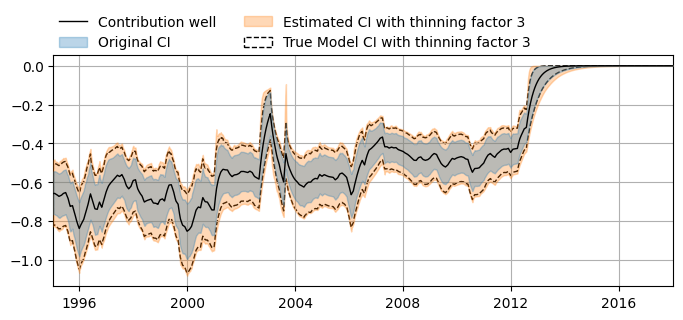

In [25]:
fig, ax = plt.subplots(figsize=(8, 3))
c = ml.get_contribution(name="well")
ax.plot(c.index, c, color="k", lw=1.0, label="Contribution well", zorder=6)
ax.fill_between(
    ci_dict[0].index,
    ci_dict[0].iloc[:, 0],
    ci_dict[0].iloc[:, 1],
    alpha=0.3,
    color="C0",
    label="Original CI",
    zorder=5,
)
ax.fill_between(
    ci_dict[tf].index,
    ci_dict[tf].iloc[:, 0],
    ci_dict[tf].iloc[:, 1],
    alpha=0.3,
    color="C1",
    label=f"Estimated CI with thinning factor {tf}",
    zorder=4,
)
ax.fill_between(
    ci2.index,
    ci2.iloc[:, 0],
    ci2.iloc[:, 1],
    facecolor="none",
    edgecolor="k",
    ls="dashed",
    lw=1.0,
    label=f"True Model CI with thinning factor {tf}",
)
ax.legend(loc=(0, 1), frameon=False, ncol=2)
ax.grid(True)
ax.set_xlim(ci_dict[0].index[0], ci_dict[0].index[-1]);

### Data worth of added observations

This example explores the data worth of adding observations relative to a model. The
head time series contains daily data, so we can explore the added worth of an
observation on any given day.

First load the data from Collenteur et al. (2019).

In [26]:
data = ps.load_dataset("collenteur_2019")

Convert the head to meters.

In [27]:
head = data["head"] * 0.3048
prec = data["rain"].reindex(
    pd.date_range(data["rain"].index[0], data["rain"].index[-1], freq="D")
)
evap = data["evap"].reindex(
    pd.date_range(data["evap"].index[0], data["evap"].index[-1], freq="D")
)

Create a model and use one observation every 90 days to calibrate the model.

The Time Series 'Rain' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


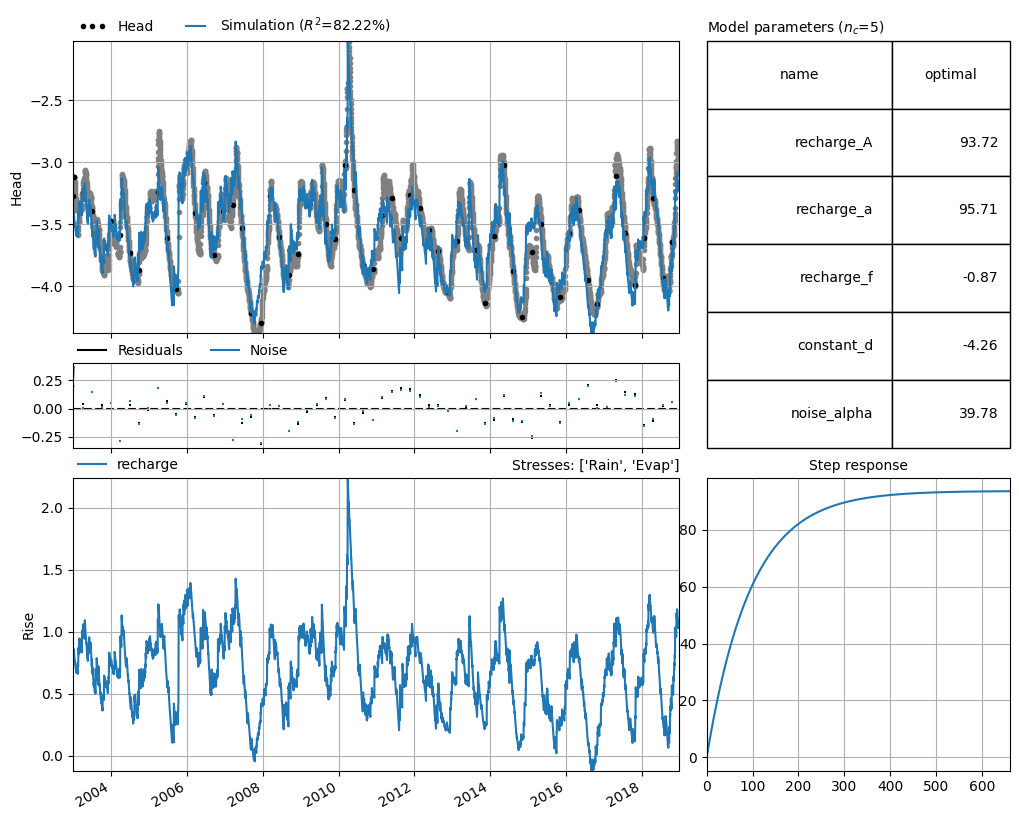

In [28]:
freq_obs = "90D"

ml = ps.Model(head)
sm = ps.RechargeModel(
    prec=prec,
    evap=evap,
    rfunc=ps.Exponential(),
    name="recharge",
)
ml.add_stressmodel(sm)
ml.solve(report=False, freq_obs=freq_obs)
ml.add_noisemodel(ps.ArNoiseModel())
ml.solve(initial=False, report=False, freq_obs=freq_obs)
axes = ml.plots.results()

Initialize the `DataWorth` class.

In [29]:
dw = ppdw.DataWorth(ml)

Compute an emperical noise_alpha to use for penalizing added observations that lie close
to the original observations, since the correlation between observations means not much
information was added.

In [30]:
# Compute residuals at all available observation times (dense)
# using the model parameters calibrated on the sparse series
resid = ml.oseries.series_original - ml.simulate().reindex(
    ml.oseries.series_original.index, method="nearest"
)

# Fit exponential decay to the empirical ACF
lags_days = np.arange(0, 180)
acf = pd.Series([resid.autocorr(lag=int(lag)) for lag in lags_days], index=lags_days)


def exp_decay(t, alpha):
    return np.exp(-t / alpha)


popt, _ = curve_fit(exp_decay, lags_days[1:], acf.iloc[1:], p0=[30])
noise_alpha_empirical = popt[0]
print(f"Empirical noise_alpha: {noise_alpha_empirical:.1f} days")

Empirical noise_alpha: 50.4 days


Compute the data worth of each potentially added observation. From the plots it is
clear that new observations, especially in the peak in 2010 would be beneficial towards
reducing parameter uncertainties.

Data Worth (new obs):   0%|          | 0/5671 [00:00<?, ?it/s]

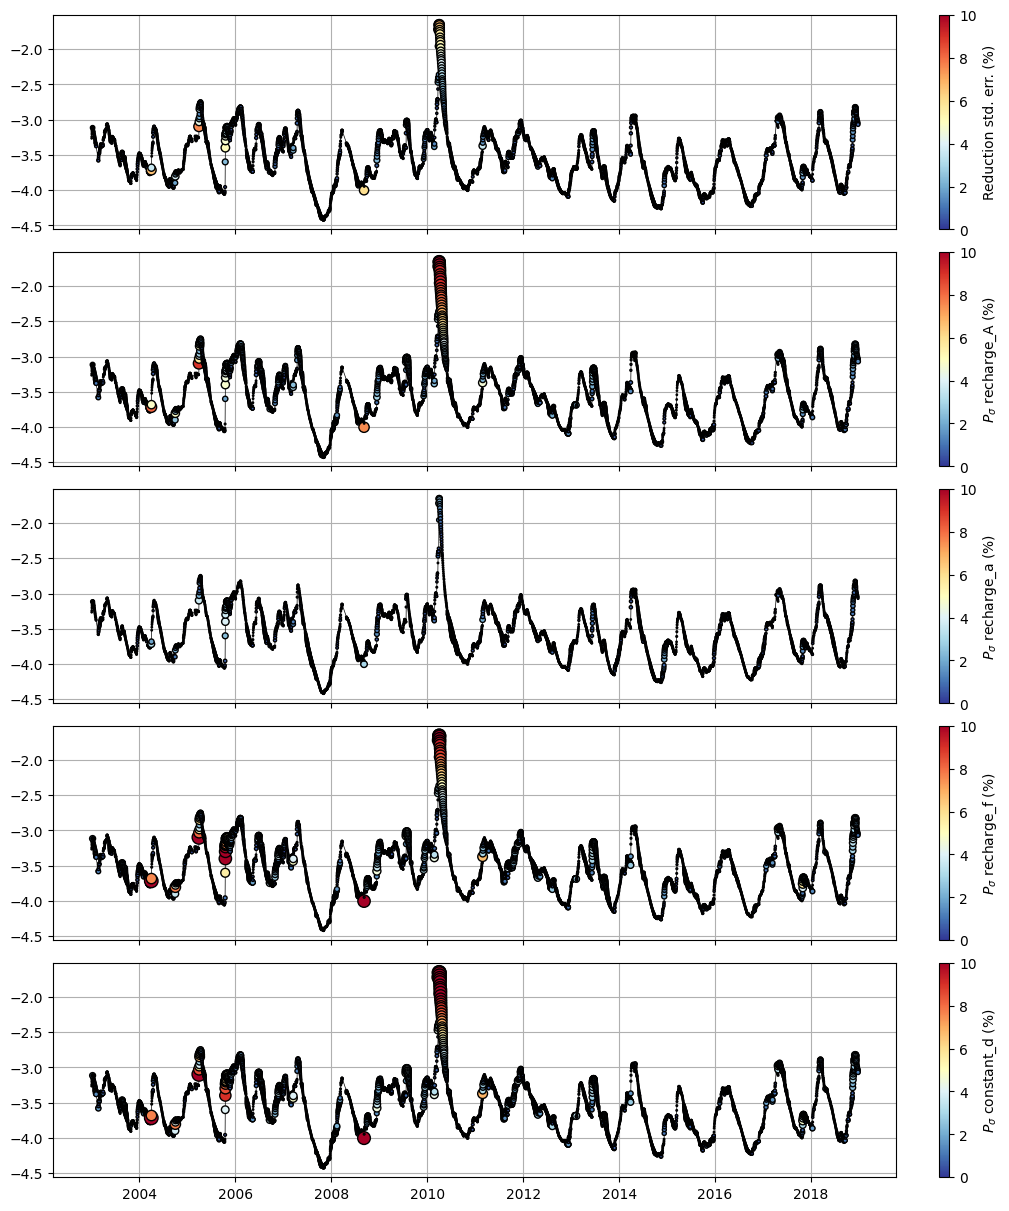

In [31]:
# Full (daily) time series — candidate pool for new observations
so = ml.oseries.series_original

# noise_alpha controls temporal correlation in C_eps (residual space).
# Higher values discount observations that are close in time to existing ones.
noise_alpha = noise_alpha_empirical  # days

# Evaluate worth of every non-calibration observation in the full series
dwdf = dw.data_worth_per_added_observation(
    so, objfun_target="residuals", noise_alpha=noise_alpha
)
# When objfun_target="residuals", noise_alpha is excluded from the Jacobian,
# so we use (n_params - 1) as the effective number of parameters.
n_params = ml.parameters.index.size - 1

# convert to change in std err
dwdf.iloc[:, 0] = (1 - np.exp(-dwdf.iloc[:, 0] / (2 * n_params))).multiply(100)
dwdf.iloc[:, 1:] = (1 - (1 - dwdf.iloc[:, 1:]).pow(0.5)) * 100

# update column names accordingly
dwdf.columns = [
    "Reduction std. err. (%)",
    "$P_\sigma$ recharge_A (%)",
    "$P_\sigma$ recharge_a (%)",
    "$P_\sigma$ recharge_f (%)",
    "$P_\sigma$ constant_d (%)",
]

axes = ppdw.plot_data_worth_series(so, dwdf, vmin=0, vmax=10)

### Effect of temporal placement on the worth of added observations

The previous analysis evaluated the worth of adding one observation at a time. Here we
ask a different question: if we were to double the number of observations by adding
one new measurement between every pair of existing 90-day calibration points, how much
does the *placement* of those new observations matter?

We parameterise placement by a time lag $\Delta t$: each new observation is placed
$\Delta t$ days before the nearest existing calibration observation. This sweeps
from $\Delta t = 1$ (new observations nearly coincide with existing ones — highly
redundant) to $\Delta t = 45$ (new observations fall almost exactly halfway between
existing ones — maximally spaced, carrying the most independent information).

The expected result is that worth should be highest when $\Delta t \approx 45$ days
(midpoint between existing observations) and drop off towards both extremes, with the
correlated $C_\epsilon$ (controlled by `noise_alpha`) governing how steeply it falls.


In [32]:
dts = [89, 87, 85, 80, 75, 60, 45, 30, 15, 10, 5, 3, 1]

# so and noise_alpha are defined in the cell above
obs_calib = ml.observations()

dw_added_obs = pd.Series(index=dts, data=np.nan)
dw_params_added_obs = pd.DataFrame(
    index=dts, columns=ml.parameters.index[:-1], data=np.nan
)

for dt in dts:
    dti = pd.Timedelta(days=dt)
    new_idx = (obs_calib.index - dti).intersection(so.index)
    new_obs = so.loc[new_idx]

    dwi, dwpi = dw.data_worth_new_observations(
        new_obs, objfun_target="residuals", noise_alpha=noise_alpha
    )
    dw_added_obs.loc[dt] = dwi
    dw_params_added_obs.loc[dt] = dwpi

Plot the results. As we can see, adding observations towards the midpoint between the
existing observations yields slightly more reduction of the uncertainty as compared to
the tail ends. The result is not quite what we would expect however, with a relatively
large peak at the lag of 89 days, and apparently in this situation adding an
observation at the 60 days point before the current observations yields the greatest
uncertainty reduction.

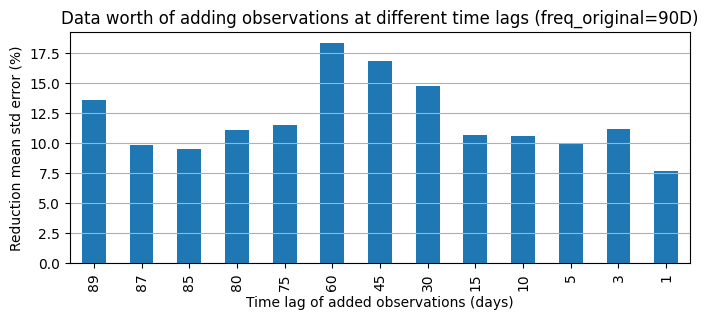

In [33]:
ax = (1 - np.exp(-dw_added_obs / (2 * n_params))).multiply(100).plot.bar(figsize=(8, 3))
ax.set_xlabel("Time lag of added observations (days)")
ax.set_ylabel("Reduction mean std error (%)")
ax.set_title(
    "Data worth of adding observations at different time lags (freq_original=90D)"
)
ax.grid(True, axis="y")

We can show the same plot per parameter.

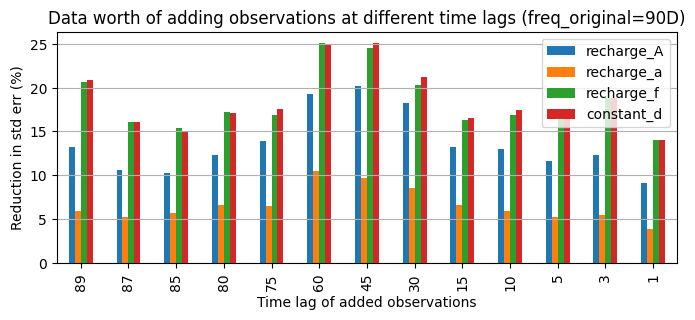

In [34]:
ax = ((1 - (1 - dw_params_added_obs).pow(0.5)) * 100).plot.bar(figsize=(8, 3))
ax.set_xlabel("Time lag of added observations")
ax.set_ylabel("Reduction in std err (%)")
ax.set_title(
    "Data worth of adding observations at different time lags (freq_original=90D)"
)
ax.grid(True, axis="y")